# Gene-level alignment for pan-genome

In [1]:
import logging
import re
import urllib
from io import StringIO
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import gzip
import pickle
from tqdm.notebook import tqdm, trange
import multiprocessing
from IPython.display import display, HTML
import itertools

import plotly.graph_objects as go

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [2]:
import os

In [3]:
from pyphylon.plotting_util import *

In [4]:
from pyphylon.plotting import *

In [5]:
from pyphylon.util import load_config

## Set up files and matrices for analysis of genomic location
Load in gene matrix and header to allele to map each gff file to correct gene names

In [6]:
CONFIG = load_config("config.yml")
SPECIES = CONFIG["PG_NAME"]
temp_folder = CONFIG.get("REUSE_TEMP_DIR", "../temp/")
data_dir = CONFIG.get("SNAKEMAKE_DATA_DIR", "data/")

In [7]:
DF_GENES = os.path.join(data_dir, f'processed/cd-hit-results/{SPECIES}_strain_by_gene.pickle.gz')
ENRICHED_METADATA = os.path.join(temp_folder, '2d_enriched_metadata.csv')
# DF_EGGNOG

In [8]:
# Set to a specific genome_id from your dataset, or leave as None to auto-select
REFERENCE_STRAIN = None

In [9]:
DF_EGGNOG = os.path.join(data_dir, f'processed/df_eggnog.csv')

In [10]:
DF_CORE_COMPLETE = os.path.join(data_dir, f'processed/CAR_genomes/df_core.csv')
DF_ACC_COMPLETE = os.path.join(data_dir, f'processed/CAR_genomes/df_acc.csv')
DF_RARE_COMPLETE = os.path.join(data_dir, f'processed/CAR_genomes/df_rare.csv')

In [11]:
df_core_complete = pd.read_csv(DF_CORE_COMPLETE, index_col=0)
df_acc_complete = pd.read_csv(DF_ACC_COMPLETE, index_col=0)
df_rare_complete = pd.read_csv(DF_RARE_COMPLETE, index_col=0)

In [12]:
# Load in (full) P matrix
df_genes = pd.read_pickle(DF_GENES)

In [13]:
metadata = pd.read_csv(ENRICHED_METADATA, index_col=0, dtype='object')
metadata = metadata[metadata['genome_id'].isin(df_genes.columns)]
metadata_complete = metadata[metadata.genome_status == 'Complete']

if REFERENCE_STRAIN is None:
    REFERENCE_STRAIN = metadata_complete.genome_id.iloc[0]
    print(f"Auto-selected REFERENCE_STRAIN: {REFERENCE_STRAIN}")

Auto-selected REFERENCE_STRAIN: 1201032.3


In [14]:
# Filter P matrix for Complete sequences only
df_genes_complete = df_genes[metadata_complete.genome_id]
df_genes_complete = df_genes_complete.fillna(0) # replace N/A with 0
df_genes_complete = df_genes_complete.sparse.to_dense().astype('int8') # densify & typecast to int8 for space and compute reasons
inCompleteseqs = df_genes_complete.sum(axis=1) > 0 # filter for genes found in complete sequences
df_genes_complete = df_genes_complete[inCompleteseqs]

df_genes_complete.shape

(8318, 355)

In [15]:
L_MATRIX = os.path.join(data_dir, f'processed/nmf-outputs/L_binarized.csv')
A_MATRIX = os.path.join(data_dir, f'processed/nmf-outputs/A_binarized.csv')

In [16]:
L_binarized = pd.read_csv(L_MATRIX, index_col=0)
A_binarized = pd.read_csv(A_MATRIX, index_col=0)

display(
    L_binarized.shape,
    L_binarized.head(),
    A_binarized.shape,
    A_binarized.head()
)

(1273, 25)

,phylon0,phylon1,phylon2,phylon3,phylon4,phylon5,phylon6,phylon7,phylon8,phylon9,...,phylon15,phylon16,phylon17,phylon18,phylon19,phylon20,phylon21,phylon22,phylon23,phylon24
CJejuni_C7641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
CJejuni_C1765,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
CJejuni_C6239,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CJejuni_C5065,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CJejuni_C2321,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


(25, 355)

,1201032.3,1211776.3,1340842.3,1347340.3,1349826.3,1349827.3,1357994.3,1380767.3,1380768.3,1383068.3,...,32022.894,32022.943,32022.944,32022.945,32022.946,354242.16,407148.6,567106.3,645464.3,718271.4
phylon0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
phylon1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
phylon2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
phylon3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
phylon4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# df_eggnog = pd.read_csv(DF_EGGNOG, low_memory=False).set_index('gene')

In [18]:
# create dict where each strain has a gene vector
strain_vectors = {}

In [19]:
from pyphylon.biointerp import get_pg_to_locus_map

In [20]:
pg2locus_map = get_pg_to_locus_map(data_dir, SPECIES)

## Functions to Parse GFF

## Get vectors of genes and binarized vectors for each strain

In [21]:
for strain in tqdm(metadata_complete.genome_id):
    DF_gff, size, oric = gff2pandas(os.path.join(data_dir, f'processed/bakta/{strain}/{strain}.gff3'))
    #DF_gff['gene'] = DF_gff.locus_tag.apply(lambda x: h2a(x, header_to_allele))
    DF_gff = pd.merge(DF_gff, pg2locus_map, left_on='locus_tag', right_on='gene_id', how='left')
    DF_gff.rename(columns={'cluster':'gene'}, inplace=True)
    DF_gff = DF_gff[DF_gff.accession == DF_gff.accession.value_counts().index[0]]
    DF_gff = DF_gff[['gene','start']]
    gene_order = (DF_gff.sort_values('start').gene.to_list())

    strain_vectors[strain] = gene_order

  0%|          | 0/355 [00:00<?, ?it/s]

In [22]:
len(strain_vectors[REFERENCE_STRAIN])

1634

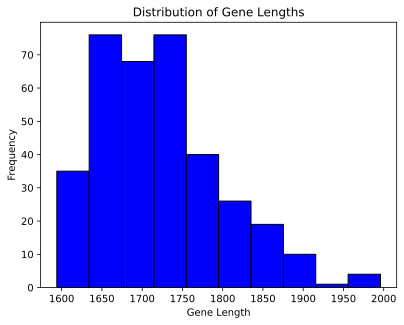

In [23]:
# Collect lengths of gene lists
gene_lengths = [len(genes) for genes in strain_vectors.values()]

# Creating the histogram
plt.hist(gene_lengths, bins=10, color='blue', edgecolor='black')

# Adding titles and labels
plt.title('Distribution of Gene Lengths')
plt.xlabel('Gene Length')
plt.ylabel('Frequency')

# Display the histogram
plt.show()

In [24]:
# Optional
# Create a new dictionary with strains having less than or equal to 6000 genes
strain_vectors_filtered = {strain: genes for strain, genes in strain_vectors.items() if len(genes) <= 6000}

## Find the genes shared between all srains and test them if they are in a certain order

In [25]:
common_gene_counts_df = count_common_gene_appearances(strain_vectors_filtered)
common_gene_counts_df

,CJejuni_C887,CJejuni_C1723,CJejuni_C3172,CJejuni_C2072,CJejuni_C4999,CJejuni_C1974,CJejuni_C1275,CJejuni_C1428,CJejuni_C2663,CJejuni_C4980,...,CJejuni_C5964,CJejuni_C2527,CJejuni_C2007,CJejuni_C3794,CJejuni_C1695,CJejuni_C1094,CJejuni_C7252,CJejuni_C1991,CJejuni_C2705,CJejuni_C4505
1201032.3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1211776.3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1340842.3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1347340.3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1349826.3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354242.16,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
407148.6,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
567106.3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
645464.3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


<Axes: >

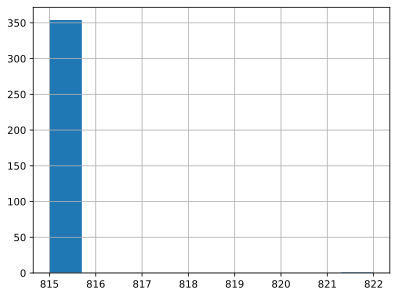

In [26]:
common_gene_counts_df.sum(axis = 1).hist()

In [27]:
common_gene_counts_df.sum(axis = 1)

1201032.3    815
1211776.3    815
1340842.3    815
1347340.3    815
1349826.3    815
            ... 
354242.16    815
407148.6     815
567106.3     815
645464.3     815
718271.4     815
Length: 355, dtype: int64

In [28]:
common_gene_count, once_gene_count, once_genes = find_once_genes(strain_vectors_filtered)
print(f"Number of common genes: {common_gene_count}")
print(f"Number of genes that appear exactly once in each strain: {once_gene_count}")

Number of common genes: 815
Number of genes that appear exactly once in each strain: 808


In [29]:
strain_groups = create_strain_groups(strain_vectors_filtered, once_genes, REFERENCE_STRAIN)

 strain_group_1: 248 strains.
 strain_group_2: 37 strains.
 strain_group_3: 1 strains.
 strain_group_4: 1 strains.
 strain_group_5: 1 strains.
 strain_group_6: 2 strains.
 strain_group_7: 1 strains.
 strain_group_8: 18 strains.
 strain_group_9: 1 strains.
 strain_group_10: 1 strains.
 strain_group_11: 1 strains.
 strain_group_12: 1 strains.
 strain_group_13: 1 strains.
 strain_group_14: 2 strains.
 strain_group_15: 1 strains.
 strain_group_16: 1 strains.
 strain_group_17: 1 strains.
 strain_group_18: 1 strains.
 strain_group_19: 1 strains.
 strain_group_20: 1 strains.
 strain_group_21: 4 strains.
 strain_group_22: 1 strains.
 strain_group_23: 4 strains.
 strain_group_24: 1 strains.
 strain_group_25: 3 strains.
 strain_group_26: 1 strains.
 strain_group_27: 1 strains.
 strain_group_28: 1 strains.
 strain_group_29: 1 strains.
 strain_group_30: 1 strains.
 strain_group_31: 1 strains.
 strain_group_32: 1 strains.
 strain_group_33: 1 strains.
 strain_group_34: 1 strains.
 strain_group_35: 1

In [30]:
# largest Group
largest_group_of_strains = max(strain_groups, key=lambda k: len(strain_groups[k]))

In [31]:
len(strain_groups[largest_group_of_strains])

248

In [32]:
strain_vectors_reference = {k: strain_vectors_filtered[k] for k in strain_groups[largest_group_of_strains] if k in strain_vectors_filtered}

## Use the largest group as reference for the order of anchor genes

In [33]:
reference_ordered_genes = get_reference_order(strain_vectors_reference, once_genes)

In [34]:
print(reference_ordered_genes)

['CJejuni_C1773', 'CJejuni_C204', 'CJejuni_C5882', 'CJejuni_C1130', 'CJejuni_C895', 'CJejuni_C6964', 'CJejuni_C3563', 'CJejuni_C644', 'CJejuni_C1315', 'CJejuni_C3342', 'CJejuni_C7790', 'CJejuni_C1086', 'CJejuni_C198', 'CJejuni_C989', 'CJejuni_C3711', 'CJejuni_C739', 'CJejuni_C3564', 'CJejuni_C515', 'CJejuni_C2413', 'CJejuni_C679', 'CJejuni_C1944', 'CJejuni_C3813', 'CJejuni_C1728', 'CJejuni_C3172', 'CJejuni_C5739', 'CJejuni_C2474', 'CJejuni_C881', 'CJejuni_C4688', 'CJejuni_C2364', 'CJejuni_C902', 'CJejuni_C624', 'CJejuni_C6620', 'CJejuni_C755', 'CJejuni_C1619', 'CJejuni_C3283', 'CJejuni_C3284', 'CJejuni_C1033', 'CJejuni_C3712', 'CJejuni_C6192', 'CJejuni_C6789', 'CJejuni_C2279', 'CJejuni_C2790', 'CJejuni_C2592', 'CJejuni_C5131', 'CJejuni_C824', 'CJejuni_C2418', 'CJejuni_C5437', 'CJejuni_C4143', 'CJejuni_C5438', 'CJejuni_C2820', 'CJejuni_C4546', 'CJejuni_C2201', 'CJejuni_C2105', 'CJejuni_C3331', 'CJejuni_C2930', 'CJejuni_C4363', 'CJejuni_C3760', 'CJejuni_C2565', 'CJejuni_C3140', 'CJejuni_

## Named these genes from 1 to N

In [35]:
# Creating the mapping dictionary
gene_mapping = {gene: idx for idx, gene in enumerate(reference_ordered_genes, start=1)}

In [36]:
len(gene_mapping.keys())

808

In [37]:
# Apply the mapping to strain_vectors_filtered, keep unmapped genes unchanged
updated_strain_vectors = {}
for strain, genes in strain_vectors_filtered.items():
    updated_genes = [gene_mapping.get(gene, gene) for gene in genes]  # Use .get() to return the gene itself if not found
    updated_strain_vectors[strain] = updated_genes

In [38]:
strain_vectors_reordered, count_reversed = adjust_gene_order(updated_strain_vectors)
print("Number of strains reordered:", count_reversed)

Number of strains reordered: 30


In [39]:
strain_vectors_final, count_reordered = reorder_to_start_with_one(strain_vectors_reordered)
print("Number of strains reordered:", count_reordered)

Number of strains reordered: 353


In [40]:
strain_vectors_final[list(strain_vectors_final.keys())[0]][:20]

[1,
 2,
 3,
 'CJejuni_C1282',
 4,
 'CJejuni_C10',
 5,
 'CJejuni_C4003',
 6,
 7,
 8,
 'CJejuni_C4340',
 9,
 10,
 'CJejuni_C795',
 11,
 'CJejuni_C548',
 'CJejuni_C2291',
 'CJejuni_C2433',
 'CJejuni_C2220']

In [41]:
sequence_check_results, total_true, total_false = check_strict_sequence(strain_vectors_final)
print("Number of strains correctly ordered:", total_true)
print("Number of strains with other orders:", total_false)

Number of strains correctly ordered: 248
Number of strains with other orders: 107


## Create gene location name for all the other genes

In [42]:
gene_mapping_to_anchor_genes = generate_gene_names(strain_vectors_final)

In [43]:
gene_mapping_to_anchor_genes[REFERENCE_STRAIN][gene_mapping_to_anchor_genes[REFERENCE_STRAIN] != 'NA'].sort_values()

CJejuni_C1612    102_1_2_103
CJejuni_C4144    102_2_1_103
CJejuni_C1119    104_1_1_105
CJejuni_C2938    108_1_1_109
CJejuni_C795       10_1_1_11
                    ...     
CJejuni_C4340        8_1_1_9
CJejuni_C4184      90_1_1_91
CJejuni_C5158      92_1_1_93
CJejuni_C3628      96_1_1_97
CJejuni_C5344     99_1_1_100
Name: 1201032.3, Length: 824, dtype: str

In [44]:
gene_count_between_anchor_genes_all = create_gene_count_between_anchor_genes_for_all(gene_mapping_to_anchor_genes)

In [45]:
gene_count_between_anchor_genes_all[REFERENCE_STRAIN]['Total Genes Between'].sum()

np.int64(824)

In [46]:
## Test if there are any missing pairs - NO Genes between these two genes
pairs = gene_count_between_anchor_genes_all[REFERENCE_STRAIN]['Anchor Genes']

# Generate the full list of expected pairs
expected_pairs = [f"{i}-{i+1}" for i in range(1, len(once_genes))]

# Find missing pairs by checking which expected pairs are not in the dataset
missing_pairs = set(expected_pairs) - set(pairs)
missing_pairs = sorted(list(missing_pairs), key=lambda x: int(x.split('-')[0]))

# Output the missing pairs
missing_pairs

['1-2',
 '2-3',
 '6-7',
 '7-8',
 '9-10',
 '12-13',
 '13-14',
 '14-15',
 '17-18',
 '19-20',
 '21-22',
 '23-24',
 '24-25',
 '25-26',
 '26-27',
 '32-33',
 '33-34',
 '34-35',
 '35-36',
 '39-40',
 '42-43',
 '43-44',
 '45-46',
 '47-48',
 '48-49',
 '49-50',
 '51-52',
 '53-54',
 '54-55',
 '55-56',
 '56-57',
 '58-59',
 '59-60',
 '60-61',
 '61-62',
 '62-63',
 '63-64',
 '66-67',
 '68-69',
 '70-71',
 '72-73',
 '73-74',
 '75-76',
 '76-77',
 '78-79',
 '79-80',
 '80-81',
 '82-83',
 '85-86',
 '88-89',
 '91-92',
 '93-94',
 '94-95',
 '95-96',
 '97-98',
 '98-99',
 '100-101',
 '101-102',
 '103-104',
 '105-106',
 '106-107',
 '107-108',
 '109-110',
 '111-112',
 '112-113',
 '113-114',
 '114-115',
 '115-116',
 '117-118',
 '119-120',
 '122-123',
 '123-124',
 '124-125',
 '126-127',
 '129-130',
 '131-132',
 '132-133',
 '133-134',
 '134-135',
 '140-141',
 '141-142',
 '142-143',
 '143-144',
 '144-145',
 '147-148',
 '149-150',
 '150-151',
 '151-152',
 '152-153',
 '155-156',
 '156-157',
 '161-162',
 '162-163',
 '164

## Identify the genetic variation in each strain

In [47]:
identify_genetic_variation(strain_vectors_final)

Variation
no variation     248
translocation     64
inversion         43
Name: count, dtype: int64


,Strain,Variation
0,1201032.3,no variation
1,1211776.3,no variation
2,1340842.3,no variation
3,1347340.3,no variation
4,1349826.3,no variation
...,...,...
350,354242.16,no variation
351,407148.6,no variation
352,567106.3,no variation
353,645464.3,no variation


## Location of the phylon

In [48]:
def rename_indexes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove 'yogenes' from all occurrences in the index.

    Parameters:
        df (pd.DataFrame): Input DataFrame with row indexes.

    Returns:
        pd.DataFrame: DataFrame with updated indexes.
    """
    df.index = df.index.str.replace('yogenes', '', regex=True)
    return df

In [49]:
L_binarized = rename_indexes(L_binarized)

## Circular plot for phylon location

### Test on MGE-2 location

In [51]:
example_strain = list(strain_vectors_final.keys())[0]
plot_circular_genome(strain_vectors_final[example_strain], L_binarized.index[L_binarized['phylon1'] == 1].tolist(), 'phylon1', example_strain)

In [52]:
unique_genes_dict = unique_genes_by_phylon(L_binarized)